In [4]:
import pandas as pd

# 读取单个 parquet 文件
file_path = "./datasets/UI-Grounding-Benchmarks/ScreenSpot-V2/data/test-00000-of-00002.parquet"
df = pd.read_parquet(file_path)

# 查看前几行数据
print(df.head())

                                     file_name  \
0  pc_ede36f9b-1154-4f76-b7f8-c15d7d3f9b6e.png   
1  pc_5e09e8e9-7ef6-44be-ad54-aeaeac151897.png   
2  pc_2c6dc6ea-fd6f-4cbb-9954-2d6a68610a48.png   
3  pc_b072d03a-51cb-4dd6-bdeb-152d3fd44e6b.png   
4  pc_ac2d2c5e-fe5a-4233-95b4-2de18ef76a9e.png   

                                               image  \
0  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
1  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
2  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
3  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
4  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   

                                                bbox  \
0  [0.9479166666666666, 0.14444444444444443, 0.99...   
1  [0.8697916666666666, 0.0, 0.9072916666666667, ...   
2  [0.7692708333333333, 0.4166666666666667, 0.865...   
3  [0.18333333333333332, 0.37407407407407406, 0.2...   
4  [0.6614583333333334, 0.6666666666666666, 0.705...   

                       in

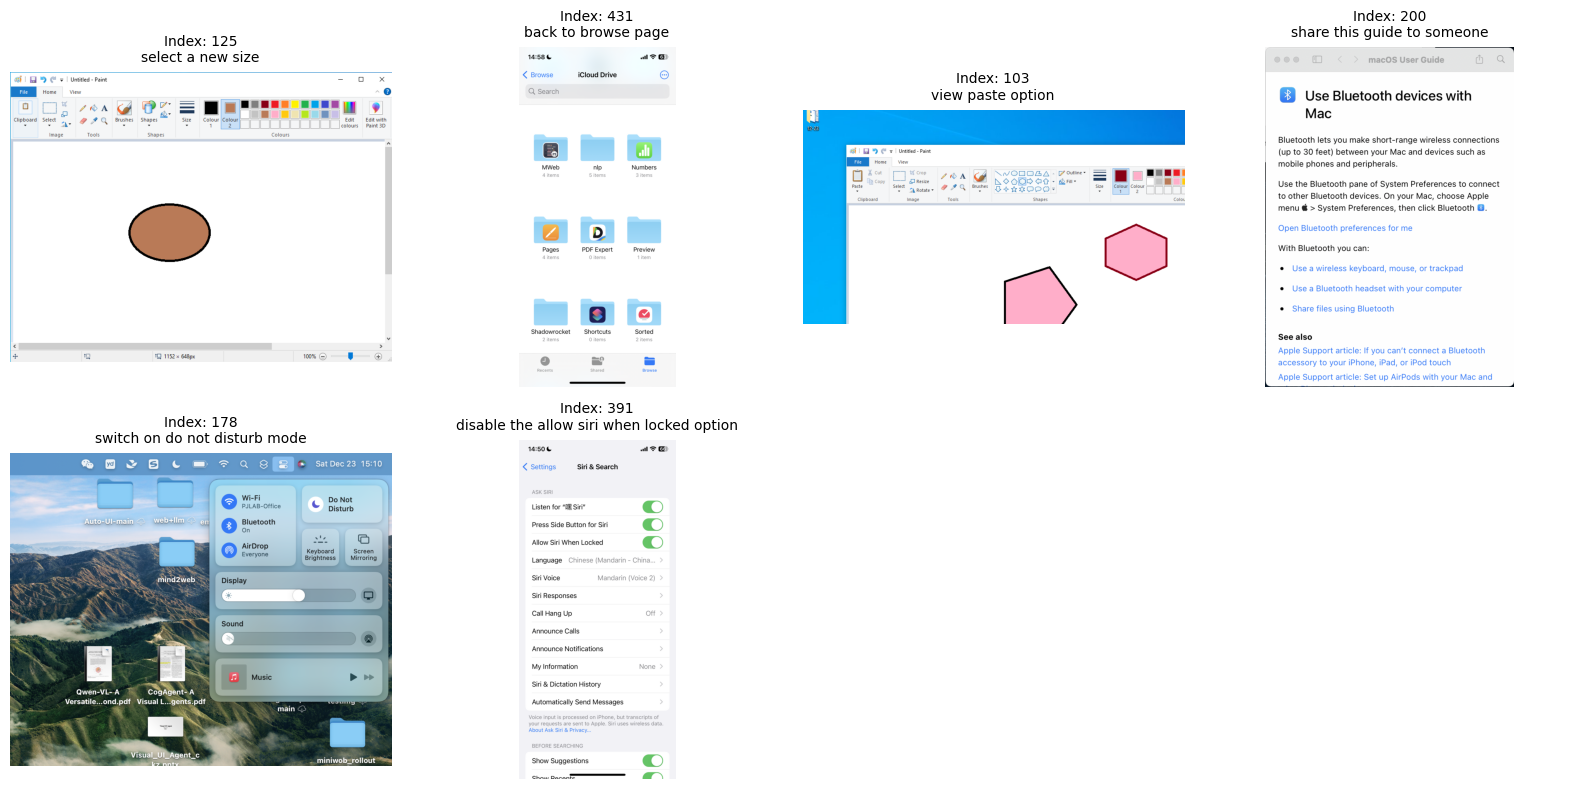

In [20]:
import io
import math
import random
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image


def show_random_images(df, num_images=2):
    """随机查看指定数量的图片并显示对应的指令。

    :param df: 包含数据的 DataFrame
    :param num_images: 想要查看的图片数量
    """
    total_rows = len(df)
    if num_images > total_rows:
        print(f"警告：请求的图片数量({num_images})超过了数据集总行数({total_rows})。已调整为最大行数。")
        num_images = total_rows

    # 1. 随机抽取索引
    random_indices = random.sample(range(total_rows), num_images)

    # 2. 自动计算网格排版（每行最多放 4 张图）
    max_cols = 4
    if num_images <= max_cols:
        cols = num_images
        rows = 1
    else:
        cols = max_cols
        rows = math.ceil(num_images / max_cols)

    # 3. 创建画布 (根据行数动态调整高度)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))

    # 如果只有 1 张图或 1 行图，将 axes 扁平化成一维数组，方便后面统一用循环处理
    if num_images == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # 4. 循环画图
    for i in range(len(axes)):
        if i < num_images:
            idx = random_indices[i]
            # 获取图片二进制数据和标签
            img_bytes = df.loc[idx, "image"]["bytes"]
            instruction = df.loc[idx, "instruction"]

            # 转换并展示图片
            image = Image.open(io.BytesIO(img_bytes))
            axes[i].imshow(image)
            axes[i].set_title(
                f"Index: {idx}\n{instruction}", fontsize=10, pad=8
            )
            axes[i].axis("off")
        else:
            # 如果网格有空余（例如要看 5 张图，网格是 2x4=8 个），隐藏多余的空白子图
            axes[i].axis("off")

    plt.tight_layout()
    plt.show()


# ================= 使用示例 =================
# 假设你已经读好了 df：
# df = pd.read_parquet("test-00000-of-00002.parquet")

# 想看 2 张图：
# show_random_images(df, num_images=2)

# 想看 6 张图（会自动排成 2 行 4 列的网格，最后留两个空位）：
show_random_images(df, num_images=6)

In [23]:
import io
import os
import pandas as pd
from PIL import Image

# 1. 假设你已经读取了数据
# df = pd.read_parquet("test-00000-of-00002.parquet")


def save_single_image(df, target_index, output_folder="saved_images"):
    """将指定索引的图片保存为本地 PNG 文件。"""
    # 检查索引是否存在
    if target_index not in df.index:
        print(f"错误：数据集中不存在索引 {target_index}")
        return

    # 创建输出文件夹
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # 提取二进制数据和指令
    img_bytes = df.loc[target_index, "image"]["bytes"]
    instruction = df.loc[target_index, "instruction"]

    # 转换并保存图片
    image = Image.open(io.BytesIO(img_bytes))

    # 文件名处理（可以用索引，也可以结合 instruction 命名）
    # 为了防止文件名包含非法字符，这里直接用 index 命名
    file_name = f"image_idx_{target_index}.png"
    file_path = os.path.join(output_folder, file_name)

    image.save(file_path, "PNG")
    print(f"成功：索引 {target_index} 的图片已保存至 -> {file_path}")
    print(f"对应指令为: {instruction}")


# ================= 使用示例 =================
# 转存索引为 4 的图片，保存到默认的 saved_images 文件夹下
idx=389
save_single_image(df, target_index=idx)
print(df.loc[idx, 'bbox'])

idx=548
save_single_image(df, target_index=idx)
print(df.loc[idx, 'bbox'])

成功：索引 389 的图片已保存至 -> saved_images/image_idx_389.png
对应指令为: view iphone storage
[0.04188034 0.59834123 0.95811966 0.64810427]
成功：索引 548 的图片已保存至 -> saved_images/image_idx_548.png
对应指令为: open message app
[0.03703704 0.5        0.27037037 0.63041667]
